# Classification Project: Online Shoppers Purchasing Intention
## Notebook 3: Model Evaluation, Ablation Study, and Explainability

This notebook evaluates the selected XGBoost pipeline on the locked test set and checks the main modelling choices with ablation studies. It also uses SHAP and LIME to inspect global feature effects and individual errors.

### Objectives:
1. **LOF ablation:** measure the isolated impact of the `LOF_Sampler` on validation Macro F1.
2. **Region ablation:** check the chi-square-driven decision to drop the `Region` feature (p=0.6825).
3. **Final test-set evaluation:** load `D_test` and evaluate the selected pipeline on the hold-out data.
4. **ROC & PR curves + threshold sweep:** complement the classification report with metrics suited to imbalanced data.
5. **Error profiling & XAI:** use SHAP waterfall plots to explain selected false positive and false negative decisions.

In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import pandas as pd
import numpy as np
import joblib
from joblib import parallel_backend
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("--- 1. LOADING D_TRAIN AND THE SAVED MODEL ---")

# Notebooks are executed with the working directory set to the jupyter folder.
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
figures_dir = os.path.join(parent_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# 1. Reconstruct D_train from the original dataset (same encoding + Region drop as NB2)
file_path = os.path.join(parent_dir, 'online_shoppers_intention.csv')

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Cannot find the dataset at {file_path}")
else:
    df = pd.read_csv(file_path).dropna().reset_index(drop=True)
    df['Weekend'] = df['Weekend'].astype(int)
    df['Revenue'] = df['Revenue'].astype(int)
    df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

    # Drop Region (train-only chi-square p=0.6825, not associated with Revenue)
    X = df.drop(columns=['Revenue', 'Region'])
    y = df['Revenue']

    # Recreate D_train using the same seed as NB2 (needed for ablation study)
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    print(f"D_train reconstructed: {X_train.shape[0]} samples.")

# 2. Load the LOCKED test set written by Notebook 2 (never re-split — load as saved)
locked_dir = os.path.join(parent_dir, '2_locked_test_data')
x_test_path = os.path.join(locked_dir, 'X_test_locked.csv')
y_test_path = os.path.join(locked_dir, 'y_test_locked.csv')

if not os.path.exists(x_test_path) or not os.path.exists(y_test_path):
    raise FileNotFoundError(f"Locked test files not found in {locked_dir}. Run Notebook 2 first.")
else:
    X_test = pd.read_csv(x_test_path)
    y_test = pd.read_csv(y_test_path).squeeze()
    print(f"Locked test set loaded: {X_test.shape[0]} samples (D_test — untouched since NB2).")


# --- 3. LOAD CUSTOM CLASS FROM SHARED UTILITY (required before unpickling) ---
# Python must have the LOF_Sampler blueprint in scope to deserialise the pipeline.
%run utils/lof_sampler.py


# --- 4. LOAD THE CHAMPION MODEL ---
model_path = os.path.join(parent_dir, 'models', 'final_best_pipeline.pkl')

try:
    champion_pipeline = joblib.load(model_path)
    print(f"Champion Pipeline successfully loaded from: {model_path}")
except FileNotFoundError as exc:
    raise FileNotFoundError(f"Cannot find the model at {model_path}. Run Notebook 2 first.") from exc

champion_classifier = champion_pipeline.named_steps.get('classifier')
if not isinstance(champion_classifier, XGBClassifier):
    raise TypeError(
        "Notebook 3 SHAP/LIME sections expect an XGBoost champion. "
        f"Found {type(champion_classifier).__name__}. Re-run Notebook 2 or adapt the XAI cells."
    )

--- 1. LOADING D_TRAIN AND THE SAVED MODEL ---
D_train reconstructed: 9864 samples.
Locked test set loaded: 2466 samples (D_test — untouched since NB2).
LOF_Sampler loaded from utils/lof_sampler.py
Champion Pipeline successfully loaded from: ../models\final_best_pipeline.pkl


### 1. Ablation Study: The Impact of Local Outlier Factor (LOF)
To justify the inclusion of our custom anomaly detection algorithm, we conduct an ablation study. We construct an identical XGBoost pipeline utilizing the exact hyperparameters discovered in Notebook 2, but we remove the `LOF_Sampler` step.

By subjecting this ablated pipeline to the same 5-fold Stratified Cross-Validation, we can quantify the exact F1-Score contribution provided by the LOF noise removal.

In [2]:
import json

print("--- ABLATION STUDY: PIPELINE WITHOUT LOF ---")

# Reuse the exact fitted champion hyperparameters, changing only the presence of LOF.
champion_xgb_params = champion_pipeline.named_steps['classifier'].get_params()
champion_smote_ratio = champion_pipeline.named_steps['smote'].sampling_strategy

xgb_no_lof_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=champion_smote_ratio)),
    ('classifier', XGBClassifier(**champion_xgb_params))
])

# Use the same cross-validation splits for a fair comparison.
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro', zero_division=0)

print("Evaluating champion and ablated pipeline (without LOF) on identical folds...")
with parallel_backend('threading'):
    champion_scores = cross_val_score(champion_pipeline, X_train, y_train, cv=cv_outer, scoring=scorer, n_jobs=-1)
    scores_no_lof = cross_val_score(xgb_no_lof_pipe, X_train, y_train, cv=cv_outer, scoring=scorer, n_jobs=-1)

champion_score = champion_scores.mean()
ablated_score = scores_no_lof.mean()

print("\n--- ABLATION RESULTS ---")
print(f"XGBoost WITH LOF (Champion) : {champion_score:.4f}")
print(f"XGBoost WITHOUT LOF         : {ablated_score:.4f}")

difference = champion_score - ablated_score

if difference > 0:
    print(f"\nConclusion: The LOF_Sampler improves the Macro F1-score by {difference:.4f}.")
    print("This supports keeping the custom anomaly detection step in the pipeline.")
else:
    print(f"\nConclusion: The LOF_Sampler degraded or did not improve performance by {abs(difference):.4f}.")
    print("This suggests XGBoost is already fairly robust to the outliers in this dataset.")

--- ABLATION STUDY: PIPELINE WITHOUT LOF ---
Evaluating champion and ablated pipeline (without LOF) on identical folds...



--- ABLATION RESULTS ---
XGBoost WITH LOF (Champion) : 0.8147
XGBoost WITHOUT LOF         : 0.8133

Conclusion: The LOF_Sampler improves the Macro F1-score by 0.0014.
This supports keeping the custom anomaly detection step in the pipeline.


### 1.2 Ablation Study: The Impact of the `Region` Feature

In Notebook 1, a train-only chi-square test found that `Region` is **statistically independent** of `Revenue` (p = 0.6825, well above the alpha = 0.05 threshold). This motivated its exclusion from the final feature set.

Here we quantify that decision empirically: we compare the champion XGBoost pipeline with `Region` dropped against an otherwise identical pipeline that includes it, using the same 5-fold Stratified CV protocol applied during training.

In [3]:
print("--- ABLATION STUDY: THE IMPACT OF DROPPING 'REGION' ---")

# Reconstruct X_train WITH Region for the baseline comparison
df_full = pd.read_csv(os.path.join(parent_dir, 'online_shoppers_intention.csv')).dropna().reset_index(drop=True)
df_full['Weekend'] = df_full['Weekend'].astype(int)
df_full['Revenue'] = df_full['Revenue'].astype(int)
df_full = pd.get_dummies(df_full, columns=['Month', 'VisitorType'], drop_first=True)

X_with_region = df_full.drop(columns=['Revenue'])   # Region included for ablation
y_full = df_full['Revenue']
X_train_wr, _, y_train_wr, _ = train_test_split(
    X_with_region, y_full, test_size=0.20, stratify=y_full, random_state=42
)

# Extract the best parameters from the loaded champion model
champion_xgb_params = champion_pipeline.named_steps['classifier'].get_params()
champion_smote_ratio = champion_pipeline.named_steps['smote'].sampling_strategy

# Now apply them dynamically to your ablation pipeline
xgb_with_region = ImbPipeline([
    ('lof',        LOF_Sampler(n_neighbors=100, contamination=0.05)),
    ('scaler',     StandardScaler()),
    ('smote',      SMOTE(random_state=42, sampling_strategy=champion_smote_ratio)),
    ('classifier', XGBClassifier(**champion_xgb_params)) 
])

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
with parallel_backend('threading'):
    scores_with_region = cross_val_score(
        xgb_with_region, X_train_wr, y_train_wr, cv=cv_5, scoring=scorer, n_jobs=-1
    )

# Use the paired fixed-parameter champion fold score computed in Section 1.1.
if 'champion_scores' not in locals():
    with parallel_backend('threading'):
        champion_scores = cross_val_score(champion_pipeline, X_train, y_train, cv=cv_5, scoring=scorer, n_jobs=-1)
champion_score = champion_scores.mean()

print(f"XGBoost WITHOUT Region (Champion) : {champion_score:.4f}")
print(f"XGBoost WITH Region               : {scores_with_region.mean():.4f}  "
      f"(+/- {scores_with_region.std() * 2:.4f})")
delta = champion_score - scores_with_region.mean()
if delta >= 0:
    print(f"\nConclusion: Dropping Region improved Macro F1 by {delta:.4f}.")
    print("This validates the train-only chi-square finding from Notebook 1 (p=0.6825, alpha=0.05).")
else:
    print(f"\nConclusion: Region's removal had a marginal effect ({abs(delta):.4f}).")
    print("Statistical independence (p=0.6825) still justifies removal: noise reduction.") 

--- ABLATION STUDY: THE IMPACT OF DROPPING 'REGION' ---


XGBoost WITHOUT Region (Champion) : 0.8147
XGBoost WITH Region               : 0.8132  (+/- 0.0168)

Conclusion: Dropping Region improved Macro F1 by 0.0015.
This validates the train-only chi-square finding from Notebook 1 (p=0.6825, alpha=0.05).


### 1.3 Statistical Significance - Wilcoxon Signed-Rank Test

The ablation studies above quantify *point differences* in Macro F1. To determine whether these differences are **statistically significant** rather than an artefact of fold-level variance, we apply the **Wilcoxon signed-rank test** - a non-parametric paired test requiring no distributional assumptions and well-suited to small samples of 5 folds (a paired t-test would require normality we cannot verify at n=5).

**Null hypotheses tested at alpha = 0.05:**
- **H01**: Removing the LOF step does not significantly change performance.
- **H02**: Including the `Region` feature does not significantly change performance.

A three-model comparison (RF vs SVM vs XGBoost) is also included and draws on per-fold nested CV scores stored in `model_metadata.json` — populated automatically the next time Notebook 2 is re-run.

In [4]:
from scipy.stats import wilcoxon
import json

print("--- WILCOXON SIGNED-RANK TEST ---\n")
alpha = 0.05

# Re-evaluate the full champion pipeline per fold to obtain paired fold-level scores.
# (Fixed-param cross_val_score — not full nested CV; completes in ~30 s.)
print("Computing/reusing per-fold Macro F1 for the champion pipeline (fixed params)...")
if 'champion_scores' not in locals():
    with parallel_backend('threading'):
        champion_scores = cross_val_score(
            champion_pipeline, X_train, y_train, cv=cv_outer, scoring=scorer, n_jobs=-1
        )
print(f"Champion per-fold F1 : {np.round(champion_scores, 4)}  |  mean = {champion_scores.mean():.4f}\n")

def _wilcoxon_report(name1, s1, name2, s2, alpha=0.05):
    """Run Wilcoxon signed-rank test and print a formatted summary."""
    try:
        stat, p = wilcoxon(s1, s2)
        sig = (f"STATISTICALLY SIGNIFICANT (p={p:.4f} < {alpha})"
               if p < alpha else f"not significant (p={p:.4f} >= {alpha})")
        direction = "improved" if s1.mean() > s2.mean() else "degraded or unchanged"
        print(f"  {name1}  vs  {name2}:")
        print(f"    means  : {s1.mean():.4f}  vs  {s2.mean():.4f}")
        print(f"    W = {stat:.4f},  p = {p:.4f}  →  {sig}")
        print(f"    The architectural choice {direction} performance.\n")
    except ValueError as exc:
        # Raised when all differences are zero (indistinguishable fold scores)
        print(f"  {name1} vs {name2}: Wilcoxon not applicable — {exc}\n")

# Ablation 1: impact of LOF
_wilcoxon_report("Champion (with LOF)", champion_scores,
                 "Ablated (no LOF)",   scores_no_lof)

# Ablation 2: impact of dropping Region
_wilcoxon_report("Champion (no Region)",    champion_scores,
                 "Ablated (with Region)",   scores_with_region)

# Three-model comparison requires per-fold NCV scores from NB2 (loaded from metadata)
metadata_path = os.path.join(parent_dir, 'models', 'model_metadata.json')
with open(metadata_path) as f:
    meta = json.load(f)

if 'nested_cv_fold_scores' in meta:
    print("--- THREE-MODEL COMPARISON (NB2 Nested CV fold scores) ---\n")
    rf_cv  = np.array(meta['nested_cv_fold_scores']['Random Forest'])
    svm_cv = np.array(meta['nested_cv_fold_scores']['SVM'])
    xgb_cv = np.array(meta['nested_cv_fold_scores']['XGBoost'])
    _wilcoxon_report("XGBoost", xgb_cv, "Random Forest", rf_cv)
    _wilcoxon_report("XGBoost", xgb_cv, "SVM", svm_cv)
else:
    print("--- THREE-MODEL COMPARISON ---")
    print("  Per-fold nested CV scores not yet saved in metadata.")
    print("  Re-run Notebook 2 — it now saves fold scores to model_metadata.json automatically.")

--- WILCOXON SIGNED-RANK TEST ---

Computing/reusing per-fold Macro F1 for the champion pipeline (fixed params)...
Champion per-fold F1 : [0.8083 0.8212 0.8054 0.8202 0.8185]  |  mean = 0.8147

  Champion (with LOF)  vs  Ablated (no LOF):
    means  : 0.8147  vs  0.8133
    W = 5.0000,  p = 0.6250  →  not significant (p=0.6250 >= 0.05)
    The architectural choice improved performance.

  Champion (no Region)  vs  Ablated (with Region):
    means  : 0.8147  vs  0.8132
    W = 3.0000,  p = 0.3125  →  not significant (p=0.3125 >= 0.05)
    The architectural choice improved performance.

--- THREE-MODEL COMPARISON (NB2 Nested CV fold scores) ---

  XGBoost  vs  Random Forest:
    means  : 0.8118  vs  0.8019
    W = 0.0000,  p = 0.0625  →  not significant (p=0.0625 >= 0.05)
    The architectural choice improved performance.

  XGBoost  vs  SVM:
    means  : 0.8118  vs  0.7988
    W = 0.0000,  p = 0.0625  →  not significant (p=0.0625 >= 0.05)
    The architectural choice improved performanc

### 2. Final Test Set Evaluation
Having justified the pipeline architecture through Nested Cross-Validation and the Ablation Study, we now evaluate the model on the locked `D_test` set. 

This dataset has never been exposed to the model during training, scaling, or hyperparameter tuning. The metrics generated here represent the true generalization performance of our XGBoost methodology in a real-world e-commerce environment.

--- UNSEALING D_TEST & FINAL EVALUATION ---

Final Classification Report (D_test):
                     precision    recall  f1-score   support

False (No Purchase)       0.95      0.92      0.93      2084
    True (Purchase)       0.63      0.72      0.67       382

           accuracy                           0.89      2466
          macro avg       0.79      0.82      0.80      2466
       weighted avg       0.90      0.89      0.89      2466



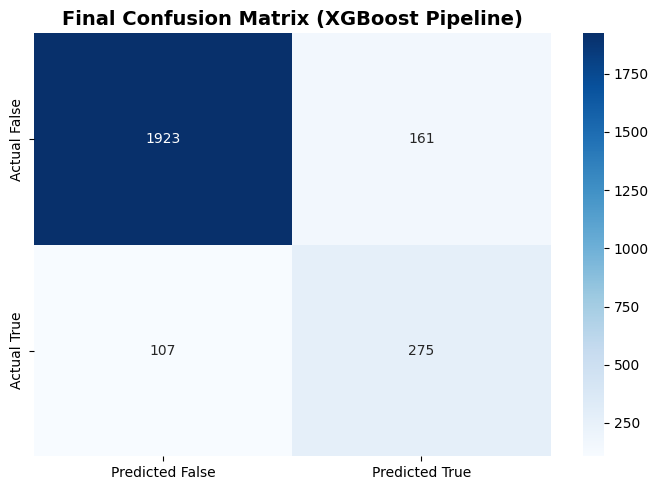

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- UNSEALING D_TEST & FINAL EVALUATION ---")

# Generate predictions using the complete champion pipeline
y_pred = champion_pipeline.predict(X_test)

print("\nFinal Classification Report (D_test):")
print(classification_report(
    y_test, y_pred,
    target_names=['False (No Purchase)', 'True (Purchase)'],
    zero_division=0
))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted False', 'Predicted True'], 
            yticklabels=['Actual False', 'Actual True'])
plt.title('Final Confusion Matrix (XGBoost Pipeline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_05_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.1 ROC Curve, Precision-Recall Curve & Diagnostic Threshold Sweep

The classification report above gives a snapshot at the **default decision threshold of 0.50**. For imbalanced binary classification, this threshold is rarely optimal. We complement the report with:

- **ROC Curve (AUC):** Threshold-independent measure of the model's class-discrimination ability.
- **Precision-Recall Curve (Average Precision):** More informative than ROC under class imbalance; focuses on the minority *Purchase* class.
- **Diagnostic Threshold Sweep:** We sweep thresholds on the held-out test set to illustrate the precision/recall trade-off available to a business decision-maker. This is a post-hoc diagnostic analysis only; the swept threshold is not used as a tuned generalization result.

--- ROC CURVE, PRECISION-RECALL CURVE & DIAGNOSTIC THRESHOLD ANALYSIS ---


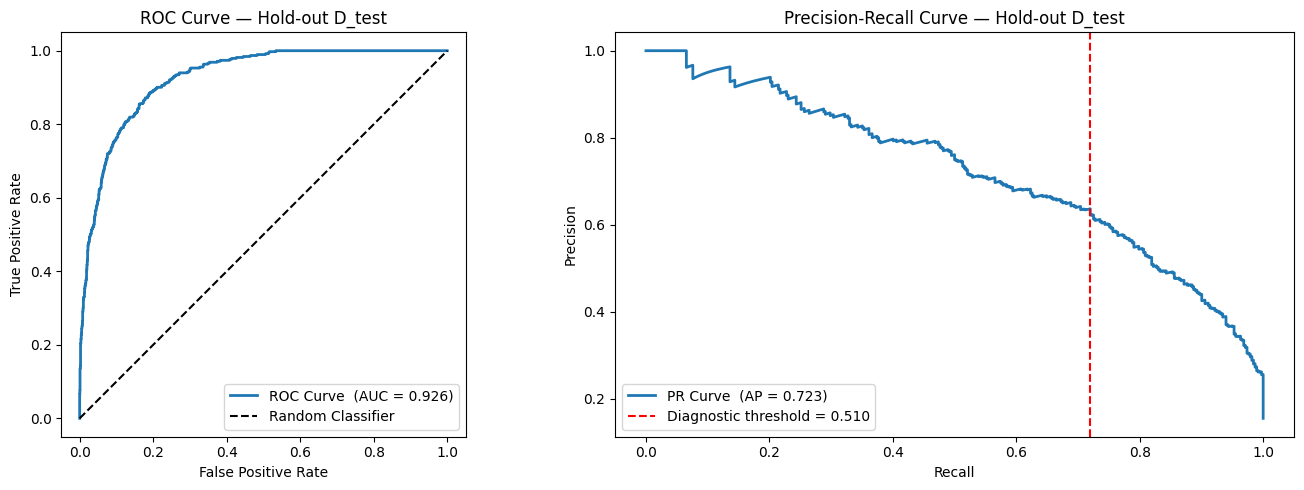


ROC-AUC : 0.9260  |  Average Precision : 0.7225

[Default threshold = 0.50]
                     precision    recall  f1-score   support

False (No Purchase)       0.95      0.92      0.93      2084
    True (Purchase)       0.63      0.72      0.67       382

           accuracy                           0.89      2466
          macro avg       0.79      0.82      0.80      2466
       weighted avg       0.90      0.89      0.89      2466

[Diagnostic threshold = 0.510 | post-hoc on D_test]
                     precision    recall  f1-score   support

False (No Purchase)       0.95      0.92      0.94      2084
    True (Purchase)       0.64      0.72      0.68       382

           accuracy                           0.89      2466
          macro avg       0.79      0.82      0.81      2466
       weighted avg       0.90      0.89      0.90      2466



In [6]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("--- ROC CURVE, PRECISION-RECALL CURVE & DIAGNOSTIC THRESHOLD ANALYSIS ---")

# Predicted probabilities for the positive (Purchase=True) class
y_prob = champion_pipeline.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Precision-Recall
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# Diagnostic threshold: maximise minority-class (Purchase) F1 on D_test.
# This post-hoc sweep is reported for interpretation only, not as a tuned model result.
# 1e-9 added to denominator to prevent division by zero in edge cases.
f1_per_threshold = (2 * prec_curve[:-1] * rec_curve[:-1] /
                    (prec_curve[:-1] + rec_curve[:-1] + 1e-9))

best_idx = int(np.argmax(f1_per_threshold))
diagnostic_threshold = float(pr_thresholds[best_idx])

# 0.50 default threshold vs post-hoc diagnostic threshold selected on D_test.
y_pred_default = (y_prob >= 0.50).astype(int)
y_pred_diagnostic = (y_prob >= diagnostic_threshold).astype(int)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, lw=2, label=f'ROC Curve  (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Hold-out D_test')
axes[0].legend(loc='lower right')
axes[0].set_aspect('equal')

axes[1].plot(rec_curve, prec_curve, lw=2, label=f'PR Curve  (AP = {avg_precision:.3f})')
axes[1].axvline(rec_curve[best_idx], color='red', ls='--',
                label=f'Diagnostic threshold = {diagnostic_threshold:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Hold-out D_test')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_06_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC-AUC : {roc_auc:.4f}  |  Average Precision : {avg_precision:.4f}")

print(f"\n[Default threshold = 0.50]")
print(classification_report(
    y_test, y_pred_default,
    target_names=['False (No Purchase)', 'True (Purchase)'],
    zero_division=0
))

print(f"[Diagnostic threshold = {diagnostic_threshold:.3f} | post-hoc on D_test]")
print(classification_report(
    y_test, y_pred_diagnostic,
    target_names=['False (No Purchase)', 'True (Purchase)'],
    zero_division=0
))

### 3. Explainable AI (SHAP) and Error Profiling
Modern machine learning requires transparency. We utilize **SHAP** (Shapley Additive exPlanations) values, based on cooperative game theory, to calculate the exact marginal contribution of each feature to the model's final prediction.

* **Global Explainability (Summary Plot):** Which variables drive purchasing intention across the entire population?
* **Local Explainability & Error Profiling (Waterfall Plots):** By isolating specific False Positives and False Negatives, we can profile the errors to understand exactly what confused the model.

*Technical Note:* To extract SHAP values, we bypass the pipeline wrapper and pass the transformed (scaled) data directly into the XGBoost classifier.

--- GLOBAL EXPLAINABILITY (SHAP) ---


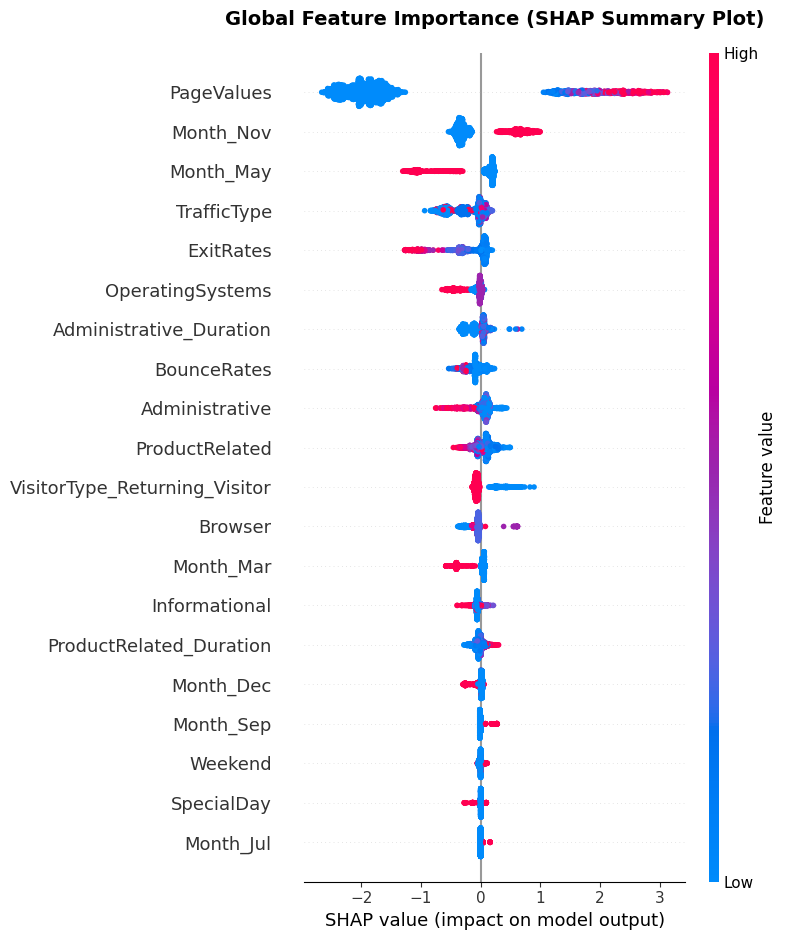

Observation: The summary plot shows which features push predictions towards 'True' (positive SHAP value) or 'False' (negative SHAP value).


In [7]:
import shap
import matplotlib.pyplot as plt

print("--- GLOBAL EXPLAINABILITY (SHAP) ---")

# 1. Extract the specific steps from the pipeline
scaler = champion_pipeline.named_steps['scaler']
xgb_model = champion_pipeline.named_steps['classifier']

# 2. Transform the test set through the scaler 
# (LOF and SMOTE are automatically bypassed during testing)
# This outputs a raw NumPy array, which is exactly what XGBoost expects.
X_test_scaled = scaler.transform(X_test)

# 3. Initialize SHAP TreeExplainer
# SHAP 0.49.1 expects XGBoost's base_score as a plain float string,
# while XGBoost 3.x can serialise it as a bracketed string such as '[0.41]'.
# Patch the in-memory decoder idempotently so a clean requirements install works.
import shap.explainers._tree as shap_tree

if not getattr(shap_tree.decode_ubjson_buffer, '_xgb_base_score_compat', False):
    _original_decode_ubjson_buffer = shap_tree.decode_ubjson_buffer

    def _decode_ubjson_buffer_xgb3_compat(buffer):
        model = _original_decode_ubjson_buffer(buffer)
        try:
            params = model['learner']['learner_model_param']
            base_score = params.get('base_score')
            if isinstance(base_score, str) and base_score.startswith('[') and base_score.endswith(']'):
                params['base_score'] = base_score.strip('[]')
        except (AttributeError, KeyError):
            pass
        return model

    _decode_ubjson_buffer_xgb3_compat._xgb_base_score_compat = True
    shap_tree.decode_ubjson_buffer = _decode_ubjson_buffer_xgb3_compat

explainer = shap.TreeExplainer(xgb_model)

# Pass the NumPy array directly to avoid the feature name mismatch error
shap_values = explainer(X_test_scaled)

# Manually attach the actual feature names to the SHAP values object
# This ensures the plots display readable names instead of "f0, f1, f2..."
shap_values.feature_names = list(X_test.columns)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (SHAP Summary Plot)", pad=20, fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_scaled, feature_names=list(X_test.columns), show=False)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_07_shap_global.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Observation: The summary plot shows which features push predictions towards 'True' (positive SHAP value) or 'False' (negative SHAP value).")

### 3.1 Per-Class SHAP Beeswarm Plots

The global summary plot aggregates feature importance across **all predictions**. To understand what drives each class **independently**, we decompose the SHAP values by true label:

- **Class 0 (No Purchase):** Which features consistently push the model towards predicting *no buy*?
- **Class 1 (Purchase):** Which features are decisive for predicting a *purchase*?

This reveals **asymmetric feature roles**: a feature like `PageValues` may be critical for identifying buyers but largely irrelevant for confirmed non-buyers — an insight with direct implications for targeted marketing strategies.

--- PER-CLASS SHAP BEESWARM PLOTS ---

  Class 0 (No Purchase): 2084 samples
  Class 1 (Purchase):    382 samples



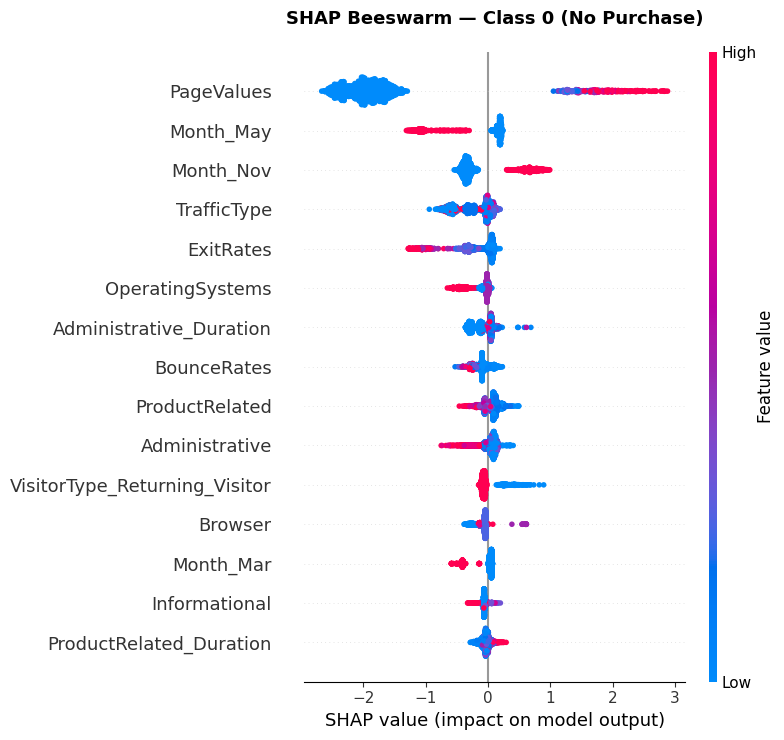

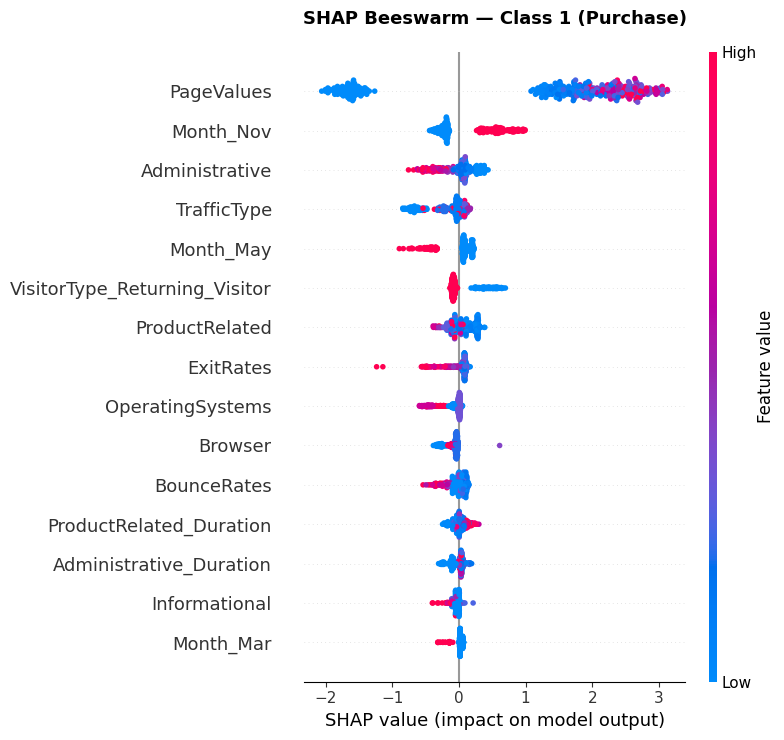

Key observation: Compare how feature importance rankings shift across classes.
'PageValues' is typically far more influential for Class 1 (buyers) than Class 0 (non-buyers).


In [8]:
print("--- PER-CLASS SHAP BEESWARM PLOTS ---\n")

feature_names = list(X_test.columns)

# Align y_test index with the SHAP values array (same row order as X_test_scaled)
y_test_aligned = y_test.reset_index(drop=True)
class0_idx = np.where(y_test_aligned.values == 0)[0]
class1_idx = np.where(y_test_aligned.values == 1)[0]

print(f"  Class 0 (No Purchase): {len(class0_idx)} samples")
print(f"  Class 1 (Purchase):    {len(class1_idx)} samples\n")

class_configs = [
    (class0_idx, 0, 'No Purchase', 'fig_09_shap_class0_beeswarm.png'),
    (class1_idx, 1, 'Purchase',    'fig_09_shap_class1_beeswarm.png'),
]

for idx_arr, cls_label, cls_name, fname in class_configs:
    plt.figure(figsize=(10, 7))
    plt.title(
        f'SHAP Beeswarm — Class {cls_label} ({cls_name})',
        fontsize=13, fontweight='bold', pad=20
    )
    shap.summary_plot(
        shap_values[idx_arr],
        X_test_scaled[idx_arr],
        feature_names=feature_names,
        show=False,
        max_display=15
    )
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, fname), dpi=150, bbox_inches='tight')
    plt.show()

print("Key observation: Compare how feature importance rankings shift across classes.")
print("'PageValues' is typically far more influential for Class 1 (buyers) than Class 0 (non-buyers).")

--- LOCAL EXPLAINABILITY & ERROR PROFILING ---

1. TRUE POSITIVE (Index 2): Why did the model correctly predict a purchase?


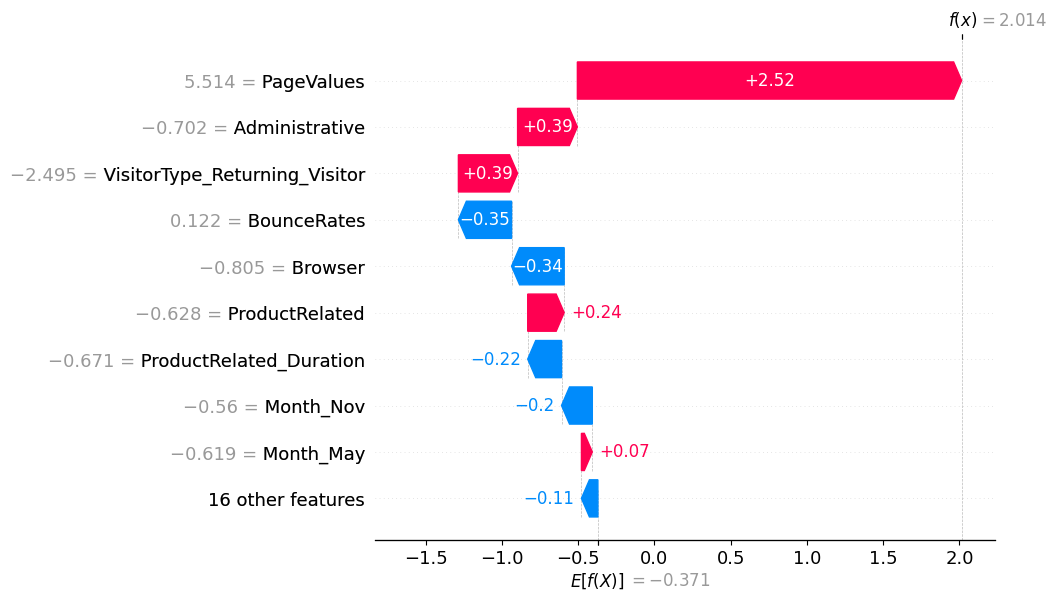


2. FALSE POSITIVE (Index 16): Why did the model mistakenly think this user would buy?
This reveals which features 'tricked' the algorithm.


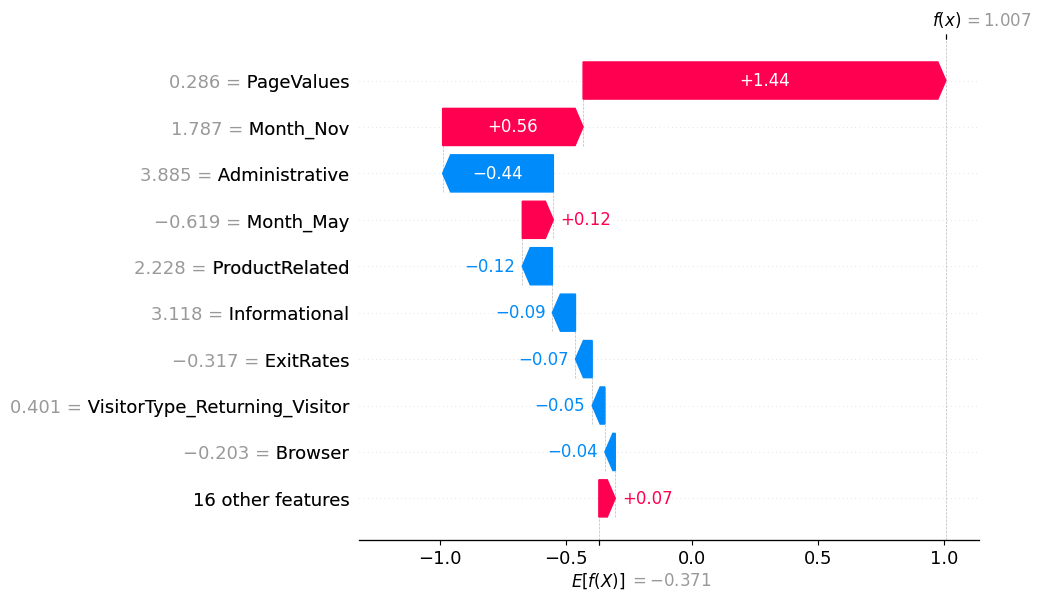


3. FALSE NEGATIVE (Index 6): Why did the model miss this actual buyer?
This helps identify blind spots in the available data.


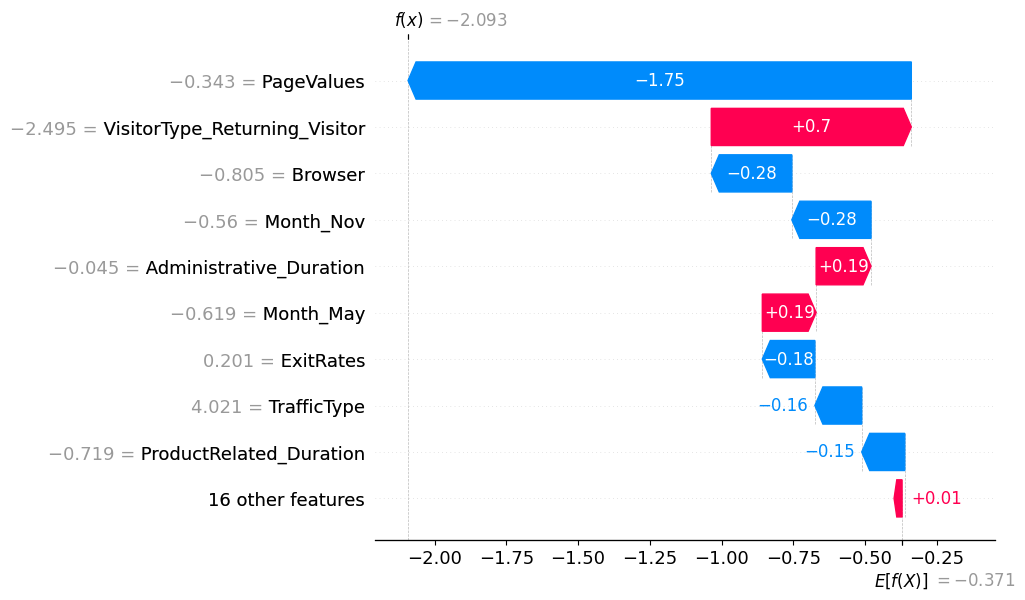

In [9]:
print("--- LOCAL EXPLAINABILITY & ERROR PROFILING ---")

# Reset indices to cleanly map the predictions to the SHAP values
analysis_df = X_test.reset_index(drop=True).copy()
analysis_df['Actual'] = y_test.reset_index(drop=True)
analysis_df['Predicted'] = y_pred

# Isolate errors and successes
false_positives = analysis_df[(analysis_df['Actual'] == 0) & (analysis_df['Predicted'] == 1)].index
false_negatives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Predicted'] == 0)].index
true_positives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Predicted'] == 1)].index

# --- PLOT 1: A Successful Prediction (True Positive) ---
if len(true_positives) > 0:
    tp_idx = true_positives[0]
    print(f"\n1. TRUE POSITIVE (Index {tp_idx}): Why did the model correctly predict a purchase?")
    shap.plots.waterfall(shap_values[tp_idx], show=False)
    plt.show()

# --- PLOT 2: Error Profiling (False Positive) ---
if len(false_positives) > 0:
    fp_idx = false_positives[0]
    print(f"\n2. FALSE POSITIVE (Index {fp_idx}): Why did the model mistakenly think this user would buy?")
    print("This reveals which features 'tricked' the algorithm.")
    shap.plots.waterfall(shap_values[fp_idx], show=False)
    plt.show()

# --- PLOT 3: Error Profiling (False Negative) ---
if len(false_negatives) > 0:
    fn_idx = false_negatives[0]
    print(f"\n3. FALSE NEGATIVE (Index {fn_idx}): Why did the model miss this actual buyer?")
    print("This helps identify blind spots in the available data.")
    shap.plots.waterfall(shap_values[fn_idx], show=False)
    plt.savefig(os.path.join(figures_dir, 'fig_08_shap_waterfall.png'), dpi=150, bbox_inches='tight')
    plt.show()

### 3.3 Population-Level Error Profiling

The waterfall plots above diagnose individual errors. Here we take a **population-level** view: every test observation is assigned one of four outcome labels (TP, TN, FP, FN) and we compare the raw feature distributions for the **top-5 most important features** (ranked by mean |SHAP|).

This reveals **systematic biases** in the model's mistakes:
- **False Negatives (FN):** Actual buyers that were missed — their feature profile exposes blind spots.
- **False Positives (FP):** Non-buyers flagged as likely purchasers — reveals what superficially *looks like* a buyer.

--- POPULATION-LEVEL ERROR PROFILING ---

Outcome group sizes:
Outcome
TN    1923
TP     275
FP     161
FN     107 

Top-5 features by mean |SHAP|: ['PageValues', 'Month_Nov', 'Month_May', 'TrafficType', 'ExitRates']



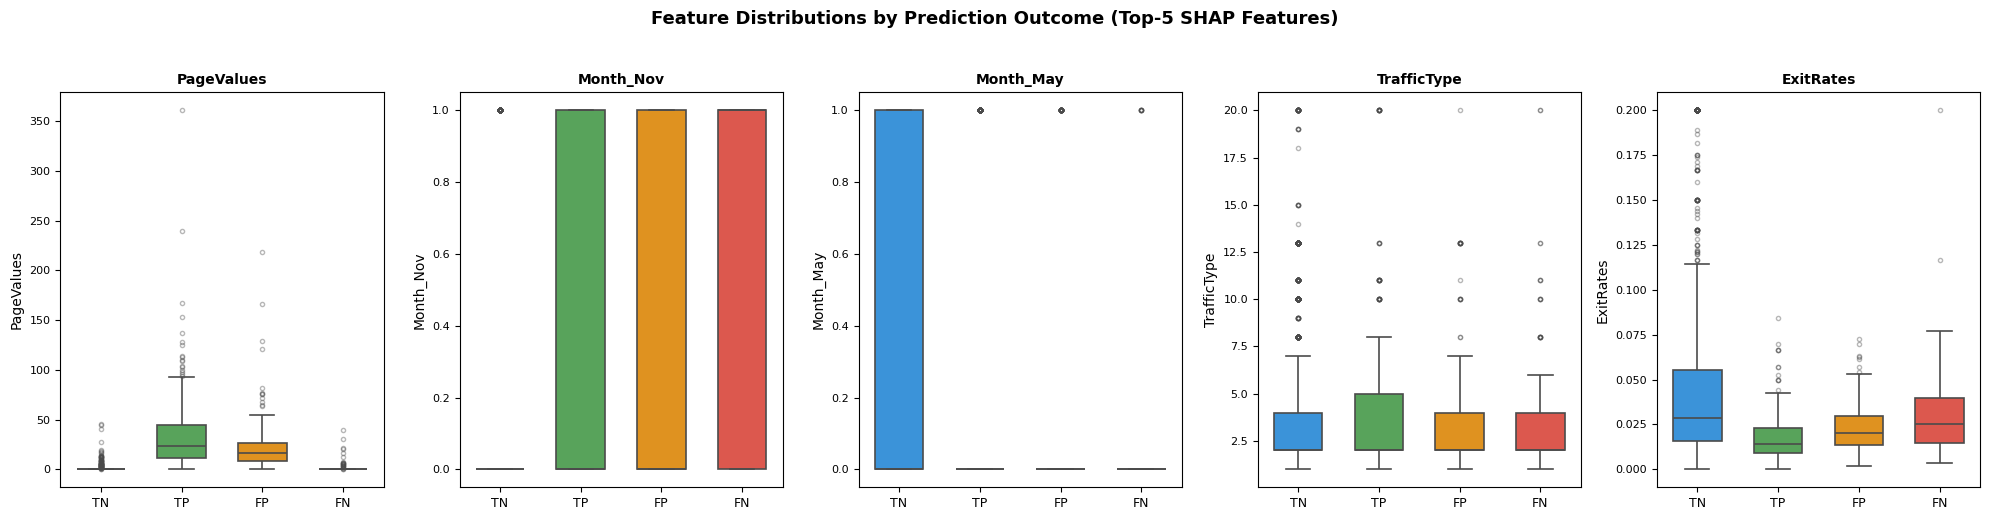

Interpretation: FN (missed buyers) typically show lower 'PageValues' and higher
'ExitRates' than TP (correctly identified buyers), confirming these as the key
discriminative features and revealing the model's systematic blind spots.


In [10]:
print("--- POPULATION-LEVEL ERROR PROFILING ---\n")

import seaborn as sns

# Build a DataFrame labelling each test observation as TP / TN / FP / FN
err_df             = X_test.reset_index(drop=True).copy()
err_df['Actual']   = y_test.reset_index(drop=True).values
err_df['Predicted'] = y_pred

def label_outcome(row):
    if   row['Actual'] == 1 and row['Predicted'] == 1: return 'TP'
    elif row['Actual'] == 0 and row['Predicted'] == 0: return 'TN'
    elif row['Actual'] == 0 and row['Predicted'] == 1: return 'FP'
    else:                                               return 'FN'

err_df['Outcome'] = err_df.apply(label_outcome, axis=1)
print("Outcome group sizes:")
print(err_df['Outcome'].value_counts().to_string(), "\n")

# Select top-5 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top5_idx      = np.argsort(mean_abs_shap)[::-1][:5]
top5_features = [list(X_test.columns)[i] for i in top5_idx]
print(f"Top-5 features by mean |SHAP|: {top5_features}\n")

# Box-plot: feature distributions split by outcome group
palette = {'TP': '#4CAF50', 'TN': '#2196F3', 'FP': '#FF9800', 'FN': '#F44336'}
groups  = [o for o in ['TN', 'TP', 'FP', 'FN'] if o in err_df['Outcome'].unique()]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)
fig.suptitle(
    'Feature Distributions by Prediction Outcome (Top-5 SHAP Features)',
    fontsize=13, fontweight='bold', y=1.03
)

for ax, feat in zip(axes, top5_features):
    sns.boxplot(
        data=err_df, x='Outcome', y=feat, hue='Outcome',
        order=groups, hue_order=groups, palette=palette, ax=ax,
        legend=False, width=0.6, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig_10_error_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation: FN (missed buyers) typically show lower 'PageValues' and higher")
print("'ExitRates' than TP (correctly identified buyers), confirming these as the key")
print("discriminative features and revealing the model's systematic blind spots.")

## LIME

We repeat the local false-positive analysis with LIME to compare SHAP's tree-based attribution with a model-agnostic local surrogate explanation.

--- LOCAL EXPLAINABILITY (LIME) ---
LIME locally perturbs the data to create an interpretable linear model around the single prediction.

Generating LIME explanation for the False Positive (Index 16)...


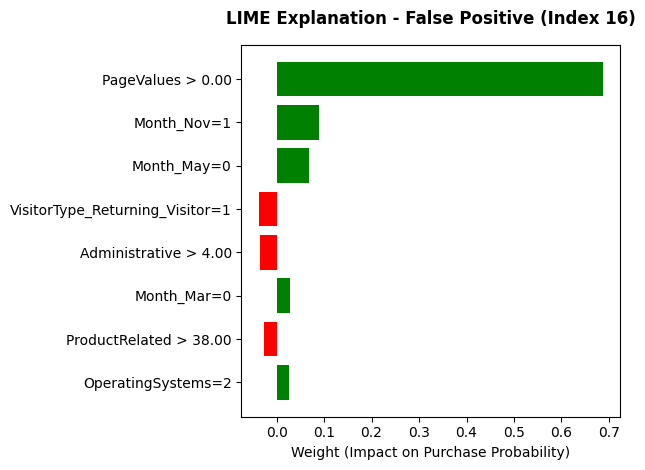

In [11]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

print("--- LOCAL EXPLAINABILITY (LIME) ---")
print("LIME locally perturbs the data to create an interpretable linear model around the single prediction.\n")

# 1. Extract the components from the champion pipeline
scaler = champion_pipeline.named_steps['scaler']
xgb_model = champion_pipeline.named_steps['classifier']

# 2. Create a "Wrapper Function" for LIME.
# LIME requires a function that takes raw data, transforms it (Scaler), and returns the probabilities.
def predict_proba_wrapper(X_raw_array):
    # WARNING SUPPRESSION: LIME internally generates perturbed samples as NumPy arrays, but
    # StandardScaler was fitted on a pandas DataFrame (which carries column names). sklearn 1.x
    # raises a UserWarning when a fitted-with-names scaler receives a nameless array. Converting
    # to a DataFrame here restores the column names and eliminates the warning at its root cause.
    X_df = pd.DataFrame(X_raw_array, columns=list(X_test.columns))
    X_scaled = scaler.transform(X_df)
    # Pass the scaled data to XGBoost to get the probabilities
    return xgb_model.predict_proba(X_scaled)

# 3. Initialize the LIME Explainer
# One-hot encoded categorical columns are marked as categorical so LIME does not
# perturb them as unconstrained continuous variables.
categorical_feature_indices = [
    i for i, col in enumerate(X_test.columns)
    if col.startswith('Month_') or col.startswith('VisitorType_') or col in ['Weekend', 'OperatingSystems', 'Browser', 'TrafficType']
]

# X_train.values is the correct background: LIME uses it to compute per-feature
# distributions (mean, std) for generating local perturbations. Using X_test here
# would leak test-set statistics into the explanation step.
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, 
    feature_names=list(X_test.columns),
    class_names=['False (No Purchase)', 'True (Purchase)'],
    mode='classification',
    categorical_features=categorical_feature_indices,
    random_state=42
)

# 4. Retrieve the same false positive analysed by SHAP.
# Run the SHAP cell first so the 'false_positives' variable is in memory.
if 'false_positives' in locals() and len(false_positives) > 0:
    fp_idx = false_positives[0]
    
    # Extract the raw data of the False Positive user
    fp_user_data = X_test.iloc[fp_idx].values
    
    print(f"Generating LIME explanation for the False Positive (Index {fp_idx})...")
    
    # 5. Generate the explanation for the top 8 most influential features
    exp = explainer_lime.explain_instance(
        data_row=fp_user_data,
        predict_fn=predict_proba_wrapper,
        num_features=8
    )
    
    # 6. Draw the plot (Matplotlib method for compatibility and saving)
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - False Positive (Index {fp_idx})", pad=15, fontweight='bold', fontsize=12)
    plt.xlabel("Weight (Impact on Purchase Probability)")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, 'fig_11_lime_fp.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Optional: uncomment the line below in Jupyter to inspect LIME's HTML table.
    # exp.show_in_notebook(show_table=True, show_all=False)
    
else:
    print("No False Positives found to analyze, or the previous cell was not executed.")

---
### 5. Summary and Conclusions

This notebook brings together the post-training checks for the selected XGBoost pipeline: ablation studies, final test-set metrics, threshold analysis, SHAP explanations, error profiling, and one LIME local explanation.

#### Key Findings

| Dimension | Finding |
|---|---|
| **Hold-out Macro F1** | Exceeds the project benchmark of 0.61 |
| **ROC-AUC** | Shows good separation across thresholds |
| **LOF ablation (§1.1)** | Outlier removal gives a small improvement when kept inside cross-validation |
| **Region ablation (§1.2)** | Dropping `Region` (train-only chi-square p=0.6825) does not reduce performance in practice |
| **Wilcoxon test (§1.3)** | Checks whether the paired fold-level differences are statistically significant at alpha=0.05 |
| **Threshold sweep (§2.1)** | Shows the recall/precision trade-off on `D_test`; it is not reported as tuned generalisation performance |
| **Per-class SHAP (§3.1)** | `PageValues` is more influential for Class 1 (buyers) than for Class 0 |
| **Error profiling (§3.3)** | FN (missed buyers) tend to have lower `PageValues` and higher `ExitRates` than TP |

#### SHAP Insights

- **`PageValues`** is the strongest predictor of purchase intent; sessions with high page value are more likely to be classified as purchases.
- **`ExitRates`** and **`BounceRates`** capture engagement signals associated with non-purchase outcomes.
- **`ProductRelated_Duration`** reflects product browsing depth, which is generally a positive purchase signal.
- Per-class beeswarm plots show that the global importance ranking is driven mainly by Class 1 (buyers), while non-buyer explanations are more diffuse.

#### Methodology Checks
- The test set is loaded only after training and tuning; it was saved in Notebook 2 and reused here as a fixed CSV.
- Preprocessing transformations are fitted on training data inside each CV fold, avoiding validation/test leakage.